
## **Laboratory Assignment 8: High-Performance Big Data Analytics**

### Problem Statement
The NYC Taxi and Limousine Commission generates millions of taxi trip records containing pickup and drop-off timestamps, locations, trip distances, passenger counts, fares, tips, and payment details.

Processing such large datasets using conventional programming approaches may increase execution time and memory consumption.

The objective of this experiment is to develop a scalable analytics solution using R and compare conventional, functional, vectorized, data.table, sequential, and parallel processing approaches.

### Objectives
1. Acquire and preprocess NYC Yellow Taxi trip data.
2. Perform transportation analytics using data.table.
3. Compare apply(), lapply(), purrr::map(), vectorized R, and data.table.
4. Compare sequential and parallel computing using foreach and doParallel.
5. Benchmark execution time and calculate speedup.
6. Visualize analytical findings using ggplot2.
7. Evaluate performance, memory efficiency, scalability, and readability.



### Dataset Description

**Dataset:** NYC TLC Yellow Taxi Trip Records  
**Source:** Official NYC Taxi and Limousine Commission website  
**Dataset period:** January 2024  
**Format:** Parquet  
**Zone lookup:** Taxi Zone Lookup Table in CSV format

The dataset contains trip timestamps, pickup and drop-off location IDs, passenger counts, trip distances, fare amounts, tip amounts, tolls, payment types, and total transaction amounts.

The Taxi Zone Lookup Table maps location IDs to zone names and boroughs.

January 2024 is used as the initial dataset because it contains a sufficiently large number of records to demonstrate data processing and performance benchmarking. The analysis can be extended to multiple months if additional scale is required.


In [1]:

packages <- c(
  "data.table",
  "arrow",
  "ggplot2",
  "foreach",
  "doParallel",
  "microbenchmark",
  "purrr",
  "lubridate"
)

for (pkg in packages)
{
  if (!requireNamespace(pkg, quietly = TRUE))
  {
    install.packages(pkg, repos = "https://cloud.r-project.org")
  }
}

library(data.table)
library(arrow)
library(ggplot2)
library(foreach)
library(doParallel)
library(microbenchmark)
library(purrr)
library(lubridate)

cat("All packages loaded successfully.\n")
cat("R version:", R.version.string, "\n")
cat("Available CPU cores:", parallel::detectCores(), "\n")


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependency ‘assertthat’


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependency ‘iterators’


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)


Attaching package: ‘data.table’


The following object is masked from ‘package:base’:

    %notin%



Attaching package: ‘arrow’


The following object is masked from ‘package:utils’:

    timestamp


Loading required package: iterators

Loading required package: parallel


Attaching package: ‘purrr’


The following objects are masked from ‘package:foreach’:

    accumulate, when


The following object is masked from ‘package:data.table’:

    transpose



Attaching package: ‘lubridate’


The following object is masked from ‘package:arrow’:

    duration


The following

All packages loaded successfully.
R version: R version 4.6.1 (2026-06-24) 
Available CPU cores: 2 



## **Task 1: Data Acquisition and Preparation**

The NYC TLC Yellow Taxi dataset is provided in Parquet format, which supports efficient columnar storage and reading. The zone lookup table is provided in CSV format.

Only the columns required for the experiment will be loaded to reduce memory consumption and unnecessary processing.


In [2]:

trip_url <- "https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2024-01.parquet"
zone_url <- "https://d37ci6vzurychx.cloudfront.net/misc/taxi_zone_lookup.csv"

trip_file <- "/content/yellow_tripdata_2024-01.parquet"
zone_file <- "/content/taxi_zone_lookup.csv"

if (!file.exists(trip_file))
{
  download.file(trip_url, trip_file, mode = "wb")
}

if (!file.exists(zone_file))
{
  download.file(zone_url, zone_file, mode = "wb")
}

cat("Trip dataset exists:", file.exists(trip_file), "\n")
cat("Zone lookup exists:", file.exists(zone_file), "\n")

print(file.info(c(trip_file, zone_file))[, c("size")])


Trip dataset exists: TRUE 
Zone lookup exists: TRUE 
[1] 49961641    12331


In [4]:
required_columns <- c(
  "tpep_pickup_datetime",
  "tpep_dropoff_datetime",
  "passenger_count",
  "trip_distance",
  "PULocationID",
  "DOLocationID",
  "payment_type",
  "fare_amount",
  "tip_amount",
  "tolls_amount",
  "total_amount"
)

taxi <- as.data.table(
  arrow::read_parquet(
    trip_file,
    col_select = required_columns
  )
)

zones <- fread(zone_file)

cat("Dataset dimensions:\n")
print(dim(taxi))

cat("\nColumn names:\n")
print(names(taxi))

cat("\nData structure:\n")
str(taxi)

cat("\nSummary statistics:\n")
print(summary(taxi))

cat("\nFirst six records:\n")
print(head(taxi))

cat("\nZone lookup dimensions:\n")
print(dim(zones))

Warning message:
“Using an external vector in selections was deprecated in tidyselect 1.1.0.
ℹ Please use `all_of()` or `any_of()` instead.
  # Was:
  data %>% select(required_columns)

  # Now:
  data %>% select(all_of(required_columns))

See <https://tidyselect.r-lib.org/reference/faq-external-vector.html>.”


Dataset dimensions:
[1] 2964624      11

Column names:
 [1] "tpep_pickup_datetime"  "tpep_dropoff_datetime" "passenger_count"      
 [4] "trip_distance"         "PULocationID"          "DOLocationID"         
 [7] "payment_type"          "fare_amount"           "tip_amount"           
[10] "tolls_amount"          "total_amount"         

Data structure:
Classes ‘data.table’ and 'data.frame':	2964624 obs. of  11 variables:
 $ tpep_pickup_datetime : POSIXct, format: "2024-01-01 00:57:55" "2024-01-01 00:03:00" ...
 $ tpep_dropoff_datetime: POSIXct, format: "2024-01-01 01:17:43" "2024-01-01 00:09:36" ...
 $ passenger_count      : int  1 1 1 1 1 1 2 0 1 1 ...
 $ trip_distance        : num  1.72 1.8 4.7 1.4 0.8 ...
 $ PULocationID         : int  186 140 236 79 211 148 138 246 161 113 ...
 $ DOLocationID         : int  79 236 79 211 148 141 181 231 261 113 ...
 $ payment_type         : int  2 1 1 1 1 1 1 2 2 2 ...
 $ fare_amount          : num  17.7 10 23.3 10 7.9 29.6 45.7 25.4 31 3 ...
 $ t


### **Data Cleaning and Transformation**

The dataset is checked for duplicate records, missing values, invalid trip distances, negative fares, invalid transaction amounts, and incorrect timestamps.

The following temporal attributes are extracted from pickup timestamps:

- Hour of the day
- Day of the month
- Day of the week
- Month

Trip duration is also calculated in minutes. Records with missing essential fields, non-positive trip distances, negative fares, invalid timestamps, or unreasonable durations are excluded from the analytical dataset.

The cleaning rules are applied consistently before conducting the analysis.


In [5]:

original_rows <- nrow(taxi)

taxi <- unique(taxi)

taxi <- taxi[
  !is.na(tpep_pickup_datetime) &
  !is.na(tpep_dropoff_datetime) &
  !is.na(trip_distance) &
  !is.na(fare_amount) &
  !is.na(total_amount) &
  !is.na(PULocationID) &
  !is.na(DOLocationID) &
  !is.na(payment_type)
]

taxi <- taxi[
  trip_distance > 0 &
  fare_amount >= 0 &
  total_amount >= 0 &
  tpep_dropoff_datetime >= tpep_pickup_datetime
]

taxi[, duration_minutes := as.numeric(
  difftime(
    tpep_dropoff_datetime,
    tpep_pickup_datetime,
    units = "mins"
  )
)]

taxi <- taxi[
  duration_minutes > 0 &
  duration_minutes <= 360
]

taxi[, pickup_hour := hour(tpep_pickup_datetime)]
taxi[, pickup_day := day(tpep_pickup_datetime)]
taxi[, day_of_week := wday(
  tpep_pickup_datetime,
  label = TRUE,
  abbr = FALSE
)]
taxi[, pickup_month := month(
  tpep_pickup_datetime,
  label = TRUE,
  abbr = FALSE
)]

cat("Rows before cleaning:", original_rows, "\n")
cat("Rows after cleaning:", nrow(taxi), "\n")
cat("Rows removed:", original_rows - nrow(taxi), "\n")

cat("\nMissing values after cleaning:\n")
print(colSums(is.na(taxi)))

cat("\nCleaned data summary:\n")
print(summary(taxi))

Rows before cleaning: 2964624 
Rows after cleaning: 2868252 
Rows removed: 96372 

Missing values after cleaning:
 tpep_pickup_datetime tpep_dropoff_datetime       passenger_count 
                    0                     0                115238 
        trip_distance          PULocationID          DOLocationID 
                    0                     0                     0 
         payment_type           fare_amount            tip_amount 
                    0                     0                     0 
         tolls_amount          total_amount      duration_minutes 
                    0                     0                     0 
          pickup_hour            pickup_day           day_of_week 
                    0                     0                     0 
         pickup_month 
                    0 

Cleaned data summary:
 tpep_pickup_datetime          tpep_dropoff_datetime         passenger_count 
 Min.   :2002-12-31 22:59:39   Min.   :2002-12-31 23:05:41   Min.   :

In [6]:
pickup_zones <- copy(zones)
setnames(
  pickup_zones,
  c("LocationID", "Borough", "Zone"),
  c("PULocationID", "pickup_borough", "pickup_zone")
)

dropoff_zones <- copy(zones)
setnames(
  dropoff_zones,
  c("LocationID", "Borough", "Zone"),
  c("DOLocationID", "dropoff_borough", "dropoff_zone")
)

taxi <- merge(
  taxi,
  pickup_zones,
  by = "PULocationID",
  all.x = TRUE,
  sort = FALSE
)

taxi <- merge(
  taxi,
  dropoff_zones,
  by = "DOLocationID",
  all.x = TRUE,
  sort = FALSE
)

cat("Joined dataset dimensions:\n")
print(dim(taxi))

cat("\nPickup borough distribution:\n")
print(taxi[, .N, by = pickup_borough][order(-N)])

cat("\nUnmatched pickup zones:", sum(is.na(taxi$pickup_zone)), "\n")
cat("Unmatched drop-off zones:", sum(is.na(taxi$dropoff_zone)), "\n")

print(head(taxi))

Joined dataset dimensions:
[1] 2868252      22

Pickup borough distribution:
   pickup_borough       N
           <char>   <int>
1:      Manhattan 2572132
2:         Queens  257681
3:       Brooklyn   22271
4:        Unknown    9617
5:          Bronx    5754
6:            N/A     701
7:            EWR      50
8:  Staten Island      46

Unmatched pickup zones: 0 
Unmatched drop-off zones: 0 
   DOLocationID PULocationID tpep_pickup_datetime tpep_dropoff_datetime
          <int>        <int>               <POSc>                <POSc>
1:           79          186  2024-01-01 00:57:55   2024-01-01 01:17:43
2:          236          140  2024-01-01 00:03:00   2024-01-01 00:09:36
3:           79          236  2024-01-01 00:17:06   2024-01-01 00:35:01
4:          211           79  2024-01-01 00:36:38   2024-01-01 00:44:56
5:          148          211  2024-01-01 00:46:51   2024-01-01 00:52:57
6:          141          148  2024-01-01 00:54:08   2024-01-01 01:26:31
   passenger_count trip_distan


## **Task 2: Transportation Data Analytics**

The cleaned and joined dataset is used to identify transportation patterns and revenue characteristics.

The analysis includes:

1. Taxi demand by hour of day.
2. Demand across days of the week.
3. Monthly taxi usage.
4. Average fares and total revenue.
5. Most frequently travelled routes.
6. Highest-revenue routes.
7. The relationship between trip distance and fare.
8. Payment preferences across boroughs.

The data.table package is used for efficient grouping, aggregation, sorting, and filtering.


In [7]:
hourly_demand <- taxi[
  ,
  .(total_trips = .N),
  by = pickup_hour
][order(pickup_hour)]

weekday_demand <- taxi[
  ,
  .(total_trips = .N),
  by = day_of_week
]

weekday_demand[, day_of_week := factor(
  day_of_week,
  levels = c(
    "Monday", "Tuesday", "Wednesday",
    "Thursday", "Friday", "Saturday", "Sunday"
  ),
  ordered = TRUE
)]

setorder(weekday_demand, day_of_week)

monthly_demand <- taxi[
  ,
  .(
    total_trips = .N,
    average_fare = mean(fare_amount, na.rm = TRUE),
    total_revenue = sum(total_amount, na.rm = TRUE)
  ),
  by = .(
    month = format(tpep_pickup_datetime, "%Y-%m")
  )
][order(month)]

print(hourly_demand)
print(weekday_demand)
print(monthly_demand)

    pickup_hour total_trips
          <int>       <int>
 1:           0       75171
 2:           1       50439
 3:           2       34937
 4:           3       22923
 5:           4       15263
 6:           5       17488
 7:           6       39395
 8:           7       80833
 9:           8      113454
10:           9      125552
11:          10      135348
12:          11      146671
13:          12      159834
14:          13      165224
15:          14      177893
16:          15      183872
17:          16      184838
18:          17      200169
19:          18      206186
20:          19      178718
21:          20      155479
22:          21      155831
23:          22      138163
24:          23      104571
    pickup_hour total_trips
          <int>       <int>
   day_of_week total_trips
         <ord>       <int>
1:      Monday      393028
2:     Tuesday      448915
3:   Wednesday      480592
4:    Thursday      416073
5:      Friday      396193
6:    Saturday      406937


In [8]:
fare_summary <- taxi[
  ,
  .(
    total_trips = .N,
    average_fare = mean(fare_amount, na.rm = TRUE),
    median_fare = median(fare_amount, na.rm = TRUE),
    average_distance = mean(trip_distance, na.rm = TRUE),
    average_duration = mean(duration_minutes, na.rm = TRUE),
    total_revenue = sum(total_amount, na.rm = TRUE)
  )
]

distance_summary <- taxi[
  ,
  .(
    average_fare = mean(fare_amount, na.rm = TRUE),
    average_total_amount = mean(total_amount, na.rm = TRUE),
    total_trips = .N
  ),
  by = .(
    distance_group = cut(
      trip_distance,
      breaks = c(0, 2, 5, 10, 20, Inf),
      labels = c(
        "0–2 miles",
        "2–5 miles",
        "5–10 miles",
        "10–20 miles",
        "20+ miles"
      ),
      include.lowest = TRUE
    )
  )
][order(distance_group)]

cat("Overall fare and revenue summary:\n")
print(fare_summary)

cat("\nFare and revenue by distance group:\n")
print(distance_summary)

cat("\nCorrelation between distance and fare:\n")
print(cor(
  taxi$trip_distance,
  taxi$fare_amount,
  use = "complete.obs"
))

Overall fare and revenue summary:
   total_trips average_fare median_fare average_distance average_duration
         <int>        <num>       <num>            <num>            <num>
1:     2868252     18.49288        12.8         3.732717         14.97272
   total_revenue
           <num>
1:      78424038

Fare and revenue by distance group:
   distance_group average_fare average_total_amount total_trips
           <fctr>        <num>                <num>       <int>
1:      0–2 miles     9.966523             16.81113     1662848
2:      2–5 miles    18.760148             26.92709      750068
3:     5–10 miles    34.039013             47.72299      230457
4:    10–20 miles    60.927572             81.49846      195969
5:      20+ miles    90.404327            114.26030       28910

Correlation between distance and fare:
[1] 0.01833689


In [9]:
route_summary <- taxi[
  !is.na(pickup_zone) & !is.na(dropoff_zone),
  .(
    total_trips = .N,
    total_revenue = sum(total_amount, na.rm = TRUE),
    average_fare = mean(fare_amount, na.rm = TRUE)
  ),
  by = .(
    pickup_borough,
    pickup_zone,
    dropoff_borough,
    dropoff_zone
  )
]

popular_routes <- route_summary[
  order(-total_trips)
][1:min(10, .N)]

revenue_routes <- route_summary[
  order(-total_revenue)
][1:min(10, .N)]

cat("Top 10 routes by trip frequency:\n")
print(popular_routes)

cat("\nTop 10 routes by total revenue:\n")
print(revenue_routes)

Top 10 routes by trip frequency:
    pickup_borough           pickup_zone dropoff_borough          dropoff_zone
            <char>                <char>          <char>                <char>
 1:      Manhattan Upper East Side South       Manhattan Upper East Side North
 2:      Manhattan Upper East Side North       Manhattan Upper East Side South
 3:      Manhattan Upper East Side North       Manhattan Upper East Side North
 4:      Manhattan Upper East Side South       Manhattan Upper East Side South
 5:      Manhattan        Midtown Center       Manhattan Upper East Side South
 6:      Manhattan   Lincoln Square East       Manhattan Upper West Side South
 7:      Manhattan Upper East Side South       Manhattan        Midtown Center
 8:      Manhattan        Midtown Center       Manhattan Upper East Side North
 9:      Manhattan Upper West Side South       Manhattan   Lincoln Square East
10:      Manhattan Upper West Side South       Manhattan Upper West Side North
    total_trips tot

In [10]:
payment_summary <- taxi[
  ,
  .(
    total_trips = .N,
    total_revenue = sum(total_amount, na.rm = TRUE)
  ),
  by = .(pickup_borough, payment_type)
][order(pickup_borough, -total_trips)]

payment_labels <- c(
  "1" = "Credit card",
  "2" = "Cash",
  "3" = "No charge",
  "4" = "Dispute",
  "5" = "Unknown",
  "6" = "Voided trip"
)

payment_summary[, payment_method := payment_labels[
  as.character(payment_type)
]]

print(payment_summary)

    pickup_borough payment_type total_trips total_revenue payment_method
            <char>        <int>       <int>         <num>         <char>
 1:          Bronx            1        4462     167038.35    Credit card
 2:          Bronx            0         817      25654.22           <NA>
 3:          Bronx            2         427      12125.47           Cash
 4:          Bronx            3          28        561.34      No charge
 5:          Bronx            4          20        710.22        Dispute
 6:       Brooklyn            1       14619     497060.67    Credit card
 7:       Brooklyn            0        5527     187323.37           <NA>
 8:       Brooklyn            2        1874      48678.46           Cash
 9:       Brooklyn            4         161       3789.58        Dispute
10:       Brooklyn            3          90       2449.91      No charge
11:            EWR            1          43       4481.06    Credit card
12:            EWR            2           4        


## **Task 3: Functional and Efficient R Programming**

Functional programming techniques allow repeated operations to be applied to multiple variables or data partitions.

In this experiment, the following approaches are compared:

- Base R vectorized operations
- apply()
- lapply()
- purrr::map()
- data.table aggregation

To ensure a fair comparison, the implementations perform equivalent calculations on the same sample of records. A smaller sample is used for the slower approaches to avoid excessive execution time.

The comparison focuses on execution time, code complexity, readability, and suitability for large datasets.


In [11]:
set.seed(42)

benchmark_size <- min(100000, nrow(taxi))

benchmark_data <- taxi[
  sample.int(nrow(taxi), benchmark_size)
]

fare_columns <- c(
  "fare_amount",
  "tip_amount",
  "tolls_amount",
  "total_amount"
)

fare_matrix <- as.matrix(
  benchmark_data[, ..fare_columns]
)

base_vectorized <- function()
{
  colMeans(fare_matrix, na.rm = TRUE)
}

apply_method <- function()
{
  apply(fare_matrix, 2, mean, na.rm = TRUE)
}

lapply_method <- function()
{
  unlist(lapply(
    as.data.frame(fare_matrix),
    mean,
    na.rm = TRUE
  ))
}

map_method <- function()
{
  unlist(purrr::map(
    as.data.frame(fare_matrix),
    ~ mean(.x, na.rm = TRUE)
  ))
}

datatable_method <- function()
{
  benchmark_data[
    ,
    lapply(.SD, mean, na.rm = TRUE),
    .SDcols = fare_columns
  ]
}

print(base_vectorized())
print(apply_method())
print(lapply_method())
print(map_method())
print(datatable_method())

 fare_amount   tip_amount tolls_amount total_amount 
  18.4634480    3.4080323    0.5349305   27.3134203 
 fare_amount   tip_amount tolls_amount total_amount 
  18.4634480    3.4080323    0.5349305   27.3134203 
 fare_amount   tip_amount tolls_amount total_amount 
  18.4634480    3.4080323    0.5349305   27.3134203 
 fare_amount   tip_amount tolls_amount total_amount 
  18.4634480    3.4080323    0.5349305   27.3134203 
   fare_amount tip_amount tolls_amount total_amount
         <num>      <num>        <num>        <num>
1:    18.46345   3.408032    0.5349305     27.31342


In [12]:
benchmark_results <- microbenchmark(
  Vectorized = base_vectorized(),
  Apply = apply_method(),
  Lapply = lapply_method(),
  Purrr_Map = map_method(),
  Data_Table = datatable_method(),
  times = 5L,
  unit = "ms"
)

print(benchmark_results)

benchmark_summary <- as.data.table(
  summary(benchmark_results)
)

benchmark_summary <- benchmark_summary[
  ,
  .(
    method = expr,
    min_ms = min,
    median_ms = median,
    mean_ms = mean
  )
][order(median_ms)]

print(benchmark_summary)

Unit: milliseconds
       expr      min       lq     mean   median       uq      max neval
 Vectorized 0.574368 0.598169 1.016586 0.619254 0.622806 2.668335     5
      Apply 6.290115 6.465722 6.857020 6.508541 6.565356 8.455367     5
     Lapply 4.943037 5.041132 5.676256 5.076393 5.139426 8.181292     5
  Purrr_Map 5.202676 5.386963 6.051456 5.442629 5.503580 8.721433     5
 Data_Table 4.895034 5.083791 5.737934 5.229342 5.455260 8.026243     5
       method   min_ms median_ms  mean_ms
       <fctr>    <num>     <num>    <num>
1: Vectorized 0.574368  0.619254 1.016586
2:     Lapply 4.943037  5.076393 5.676256
3: Data_Table 4.895034  5.229342 5.737934
4:  Purrr_Map 5.202676  5.442629 6.051456
5:      Apply 6.290115  6.508541 6.857020



## **Task 4: Parallel Computing**

Parallel computing divides a computational task into independent partitions that can be processed simultaneously by multiple CPU cores.

For this experiment, the dataset is divided into row-based partitions. Each partition calculates the number of trips and total revenue for every pickup hour.

The same operation is implemented using:

1. Sequential processing with lapply().
2. Parallel processing with foreach and doParallel.

The execution time of both approaches is measured. Speedup is calculated as:

**Speedup = Sequential Execution Time / Parallel Execution Time**

Parallel execution is not guaranteed to be faster because worker startup, data transfer, memory use, and task scheduling introduce overhead.


In [18]:

cat("Rows in taxi:", nrow(taxi), "\n")
cat("Rows in parallel_data:", nrow(parallel_data), "\n")
cat("Detected CPU cores:", parallel::detectCores(), "\n")


Rows in taxi: 2868252 
Rows in parallel_data: 2868252 
Detected CPU cores: 2 


In [19]:

parallel_data <- taxi[
  ,
  .(pickup_hour, total_amount)
]

number_of_partitions <- min(4L, nrow(parallel_data))

partition_ids <- rep(
  seq_len(number_of_partitions),
  length.out = nrow(parallel_data)
)

partitions <- split(parallel_data, partition_ids)

cat("Total records:", nrow(parallel_data), "\n")
cat("Number of partitions:", length(partitions), "\n")
print(lengths(partitions))

Total records: 2868252 
Number of partitions: 4 
1 2 3 4 
2 2 2 2 



## **Task 5: Performance Benchmarking and Optimization**

Performance benchmarking measures the execution time of alternative implementations performing equivalent operations.

The experiment compares vectorized R, apply(), lapply(), purrr::map(), and data.table. Sequential and parallel processing are also evaluated separately.

The median execution time is used to reduce the influence of unusually fast or slow individual runs.

Performance conclusions must be based on the measured results rather than assumed speed differences. Memory consumption and scalability are discussed separately because execution time alone does not fully describe performance.

In [20]:

grouping_data <- data.frame(
  pickup_hour = benchmark_data$pickup_hour,
  total_amount = benchmark_data$total_amount
)

base_grouping <- function()
{
  aggregate(
    total_amount ~ pickup_hour,
    data = grouping_data,
    FUN = sum
  )
}

datatable_grouping <- function()
{
  benchmark_data[
    ,
    .(total_revenue = sum(total_amount, na.rm = TRUE)),
    by = pickup_hour
  ]
}

grouping_benchmark <- microbenchmark(
  Base_R = base_grouping(),
  Data_Table = datatable_grouping(),
  times = 5L,
  unit = "ms"
)

print(grouping_benchmark)
print(summary(grouping_benchmark))

Unit: milliseconds
       expr       min        lq      mean   median        uq       max neval
     Base_R 78.344488 78.635832 79.457726 78.84588 79.279935 82.182494     5
 Data_Table  4.012666  4.034909  4.778987  4.21639  4.371486  7.259484     5
        expr       min        lq      mean   median        uq       max neval
1     Base_R 78.344488 78.635832 79.457726 78.84588 79.279935 82.182494     5
2 Data_Table  4.012666  4.034909  4.778987  4.21639  4.371486  7.259484     5



## **Task 6: Data Visualization**

The ggplot2 package is used to visualize the analytical results.

The visualizations include hourly taxi demand, weekday demand, monthly demand, revenue by hour, popular routes, payment preferences, and the relationship between trip distance and fare amount.

Each visualization contains a title and appropriate axis labels. The charts are used to identify demand patterns, revenue characteristics, and passenger payment preferences.

Note: A single month of data supports hourly and weekday comparisons, but a meaningful month-to-month comparison requires multiple months of records.

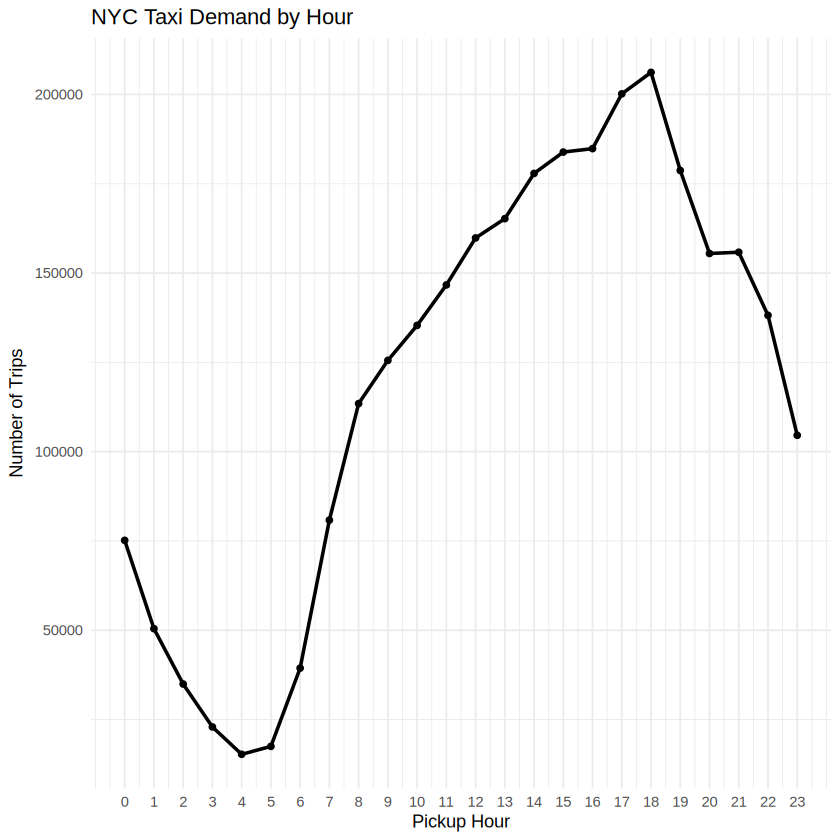

In [21]:
ggplot(hourly_demand, aes(
  x = pickup_hour,
  y = total_trips
)) +
  geom_line(linewidth = 1) +
  geom_point() +
  scale_x_continuous(breaks = 0:23) +
  labs(
    title = "NYC Taxi Demand by Hour",
    x = "Pickup Hour",
    y = "Number of Trips"
  ) +
  theme_minimal()

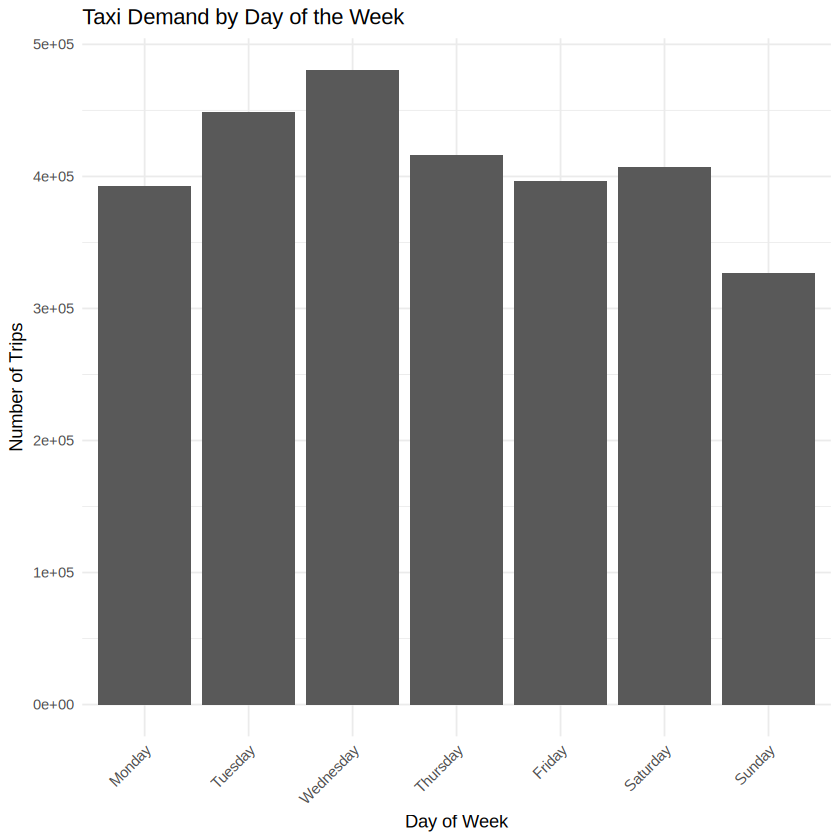

In [22]:
ggplot(weekday_demand, aes(
  x = day_of_week,
  y = total_trips
)) +
  geom_col() +
  labs(
    title = "Taxi Demand by Day of the Week",
    x = "Day of Week",
    y = "Number of Trips"
  ) +
  theme_minimal() +
  theme(axis.text.x = element_text(
    angle = 45,
    hjust = 1
  ))

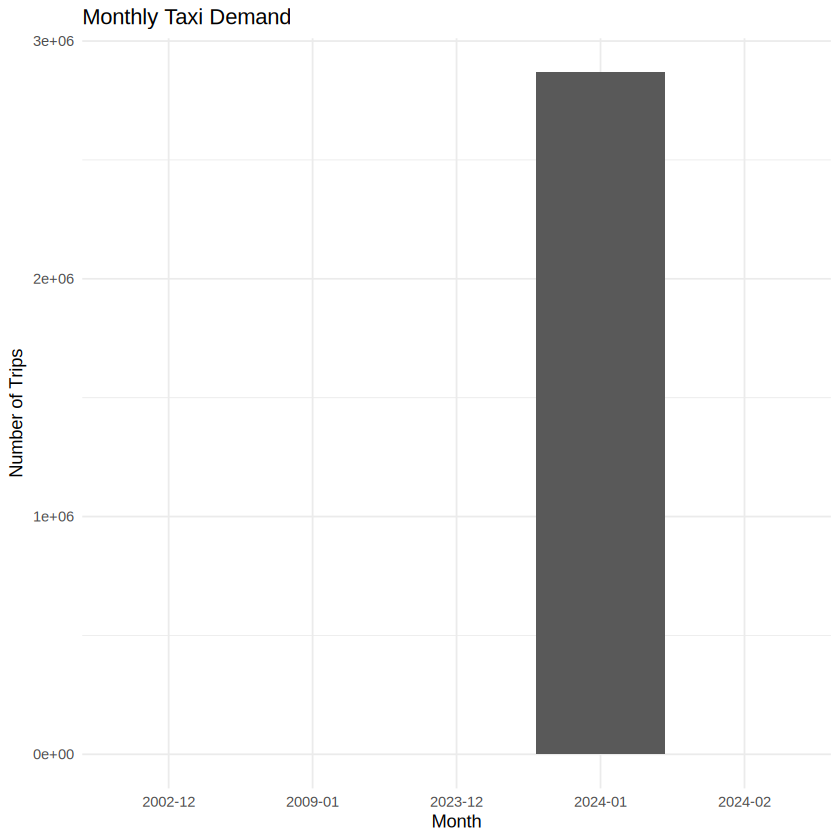

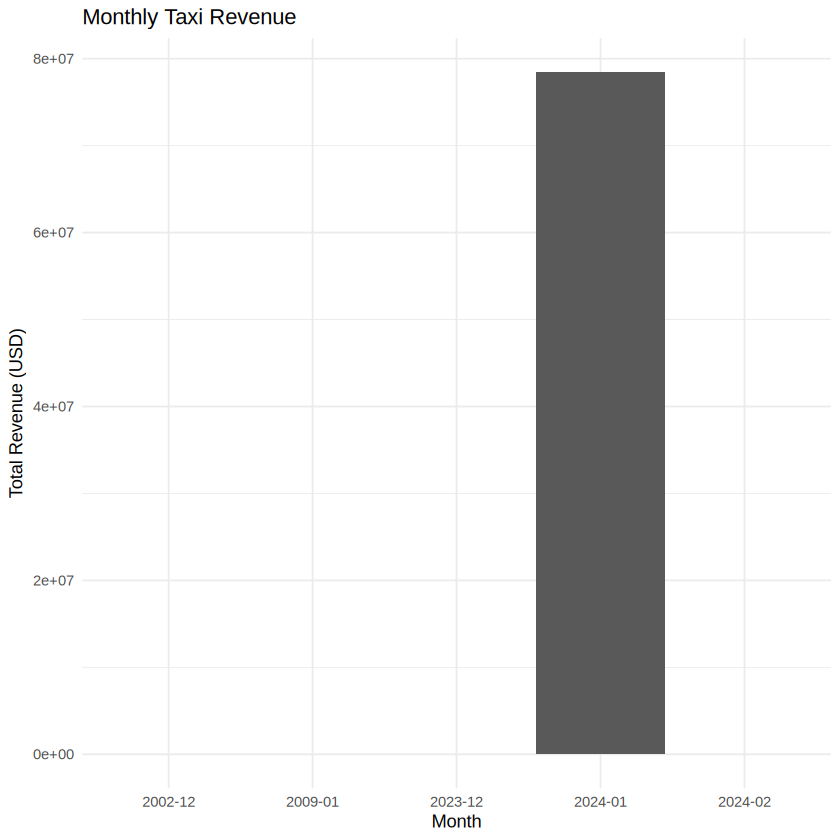

In [23]:

ggplot(monthly_demand, aes(
  x = month,
  y = total_trips
)) +
  geom_col() +
  labs(
    title = "Monthly Taxi Demand",
    x = "Month",
    y = "Number of Trips"
  ) +
  theme_minimal()

ggplot(monthly_demand, aes(
  x = month,
  y = total_revenue
)) +
  geom_col() +
  labs(
    title = "Monthly Taxi Revenue",
    x = "Month",
    y = "Total Revenue (USD)"
  ) +
  theme_minimal()


`geom_smooth()` using formula = 'y ~ x'


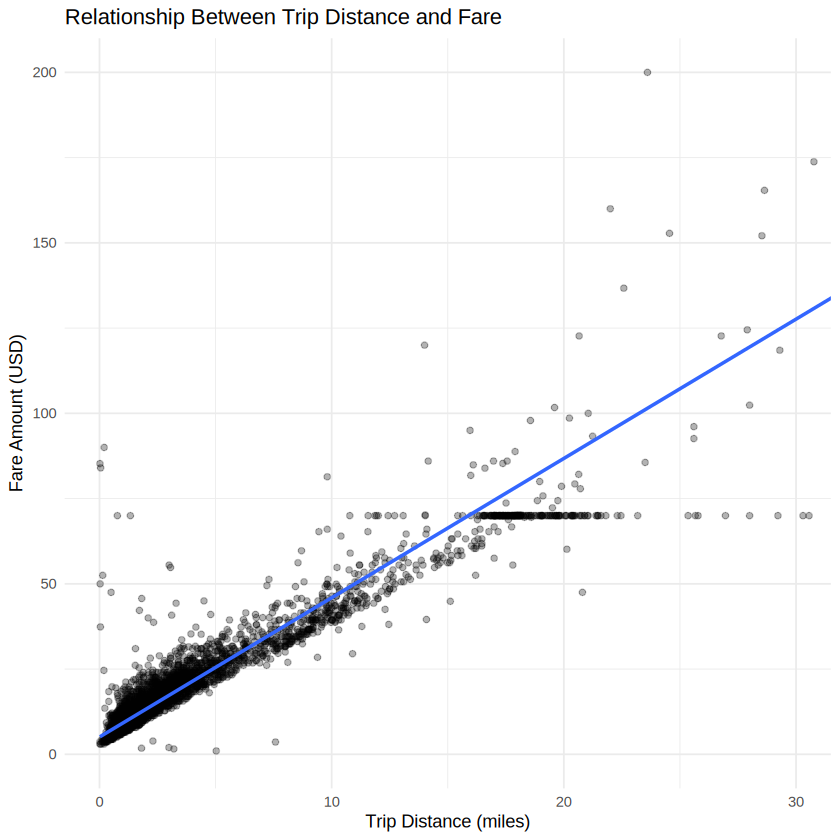

In [24]:

set.seed(42)

plot_size <- min(5000L, nrow(taxi))
plot_data <- taxi[
  sample.int(nrow(taxi), plot_size)
]

ggplot(plot_data, aes(
  x = trip_distance,
  y = fare_amount
)) +
  geom_point(alpha = 0.3) +
  geom_smooth(method = "lm", se = FALSE) +
  coord_cartesian(
    xlim = c(0, 30),
    ylim = c(0, 200)
  ) +
  labs(
    title = "Relationship Between Trip Distance and Fare",
    x = "Trip Distance (miles)",
    y = "Fare Amount (USD)"
  ) +
  theme_minimal()

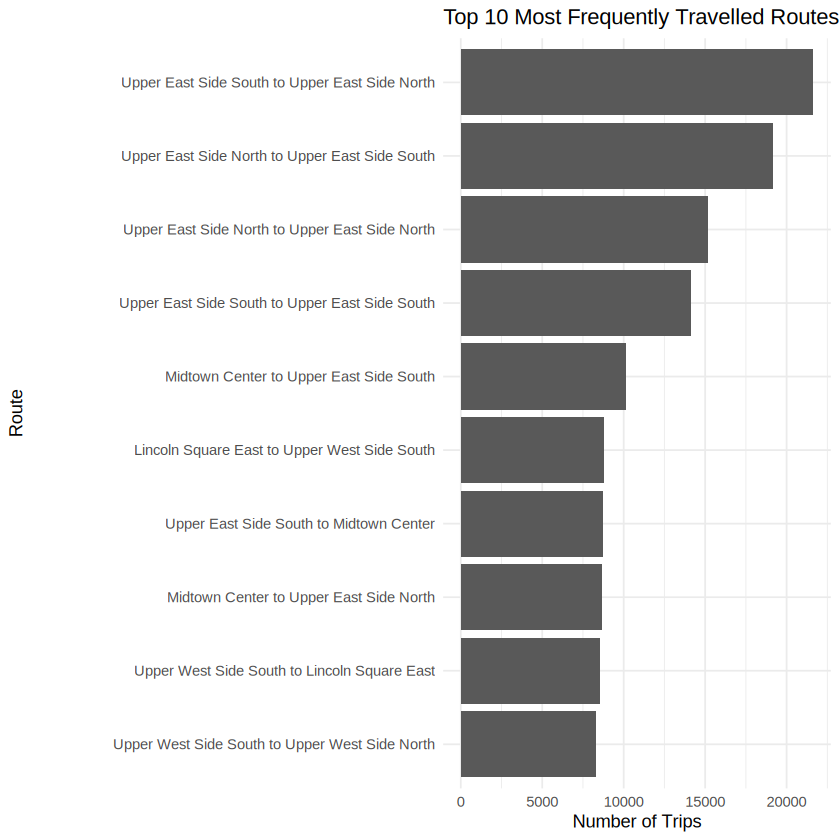

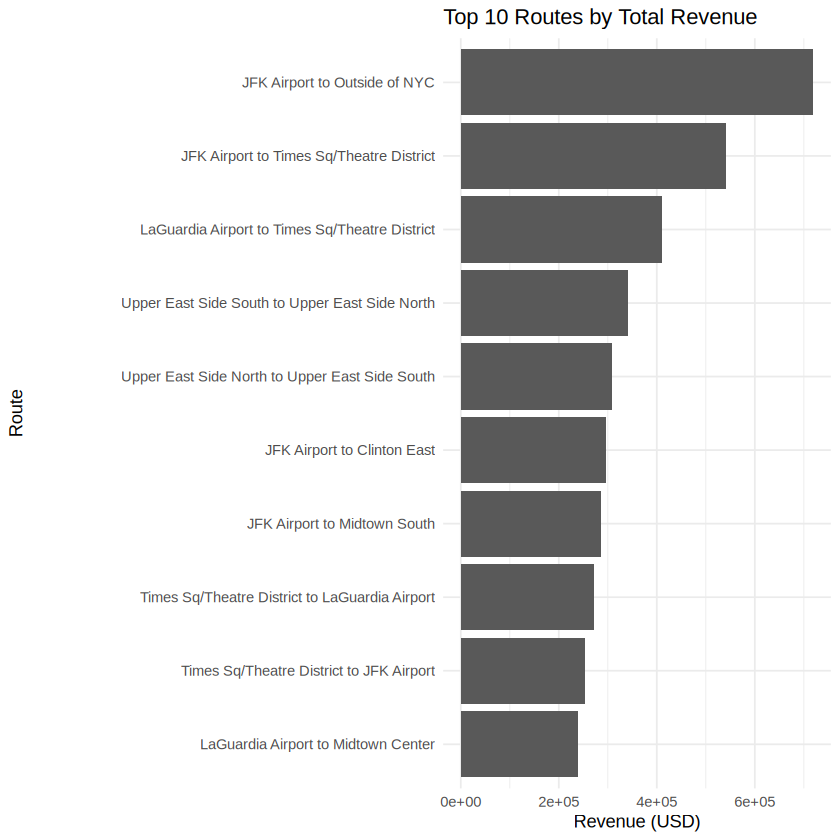

In [25]:

popular_routes[, route := paste(
  pickup_zone,
  "to",
  dropoff_zone
)]

ggplot(popular_routes, aes(
  x = reorder(route, total_trips),
  y = total_trips
)) +
  geom_col() +
  coord_flip() +
  labs(
    title = "Top 10 Most Frequently Travelled Routes",
    x = "Route",
    y = "Number of Trips"
  ) +
  theme_minimal()

revenue_routes[, route := paste(
  pickup_zone,
  "to",
  dropoff_zone
)]

ggplot(revenue_routes, aes(
  x = reorder(route, total_revenue),
  y = total_revenue
)) +
  geom_col() +
  coord_flip() +
  labs(
    title = "Top 10 Routes by Total Revenue",
    x = "Route",
    y = "Revenue (USD)"
  ) +
  theme_minimal()


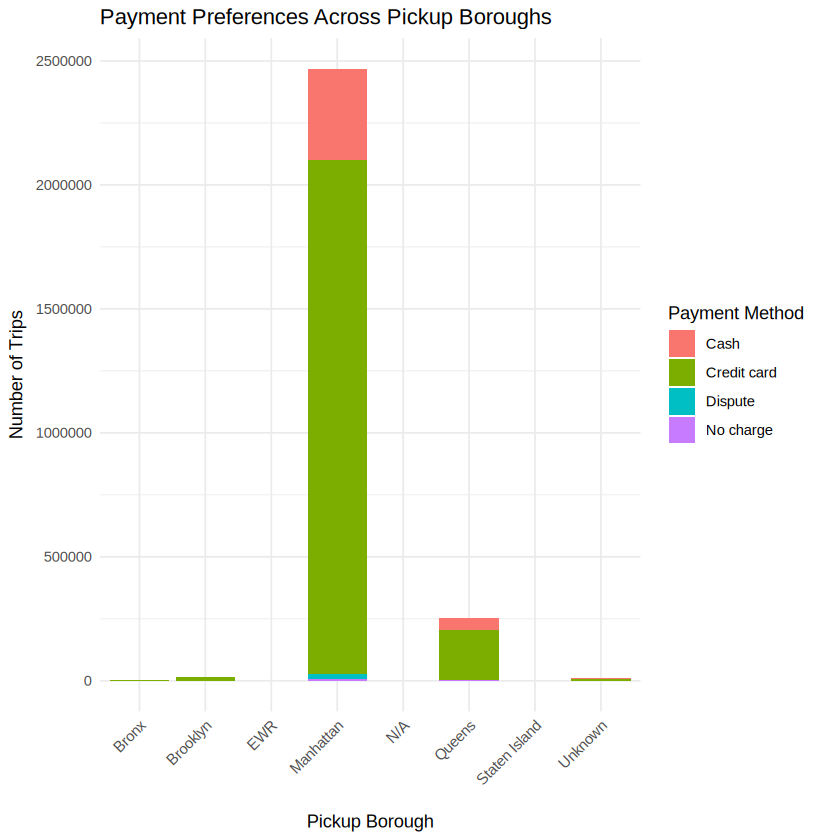

In [26]:

payment_plot <- payment_summary[
  !is.na(payment_method) &
  !is.na(pickup_borough)
]

ggplot(payment_plot, aes(
  x = pickup_borough,
  y = total_trips,
  fill = payment_method
)) +
  geom_col() +
  labs(
    title = "Payment Preferences Across Pickup Boroughs",
    x = "Pickup Borough",
    y = "Number of Trips",
    fill = "Payment Method"
  ) +
  theme_minimal() +
  theme(axis.text.x = element_text(
    angle = 45,
    hjust = 1
  ))



## **Task 7: Critical Analysis and Recommendation**

The experimental results are used to evaluate the suitability of alternative R programming approaches.

### Evaluation Criteria

1. Execution time: Time required to complete an operation.
2. Memory utilization: Amount of memory required to store and process data.
3. Scalability: Ability to process increasing dataset sizes.
4. Readability: Ease of understanding and maintaining the code.
5. Computational overhead: Additional cost introduced by function calls, data copying, and parallel execution.

### Expected Technical Interpretation

- Vectorized operations often perform well for straightforward calculations on entire vectors.
- apply(), lapply(), and purrr::map() improve the organization of repeated operations, but their performance depends on the operation and data structure.
- data.table is suitable for large datasets because it provides efficient grouping, filtering, joins, and by-reference updates.
- Parallel computing can improve performance when independent tasks are sufficiently computationally intensive.
- Parallel processing may be slower for small tasks because of worker startup, scheduling, and data-transfer overhead.

The final recommendation must be supported by the measured results of the experiment.

In [27]:

cat("EXPERIMENTAL RESULTS REPORT\n")
cat("==========================\n\n")

cat("1. DATASET\n")
cat("Cleaned records:", format(nrow(taxi), big.mark = ","), "\n")
cat("Columns:", ncol(taxi), "\n")
cat(
  "Approximate in-memory size:",
  round(as.numeric(object.size(taxi)) / 1024^2, 2),
  "MB\n\n"
)

cat("2. TRANSPORTATION ANALYSIS\n")
cat("Average fare (USD):",
    round(fare_summary$average_fare, 2), "\n")
cat("Average trip distance (miles):",
    round(fare_summary$average_distance, 2), "\n")
cat("Average duration (minutes):",
    round(fare_summary$average_duration, 2), "\n")
cat("Total recorded revenue (USD):",
    round(fare_summary$total_revenue, 2), "\n\n")

cat("3. MOST ACTIVE HOUR\n")
print(hourly_demand[which.max(total_trips)])

cat("\n4. BUSIEST WEEKDAY\n")
print(weekday_demand[which.max(total_trips)])

cat("\n5. BENCHMARK WINNER BY MEDIAN TIME\n")
print(benchmark_summary[1])

cat("\n6. SEQUENTIAL AND PARALLEL COMPARISON\n")
print(timing_comparison)
cat("Measured speedup:", round(speedup, 3), "x\n")

if (speedup > 1)
{
  cat("Parallel processing was faster in this experiment.\n")
} else if (speedup < 1)
{
  cat("Sequential processing was faster in this experiment.\n")
} else
{
  cat("Both approaches had approximately equal execution time.\n")
}

cat("\n7. SESSION INFORMATION\n")
print(sessionInfo())


EXPERIMENTAL RESULTS REPORT

1. DATASET
Cleaned records: 2,868,252 
Columns: 22 
Approximate in-memory size: 393.94 MB

2. TRANSPORTATION ANALYSIS
Average fare (USD): 18.49 
Average trip distance (miles): 3.73 
Average duration (minutes): 14.97 
Total recorded revenue (USD): 78424038 

3. MOST ACTIVE HOUR
   pickup_hour total_trips
         <int>       <int>
1:          18      206186

4. BUSIEST WEEKDAY
   day_of_week total_trips
         <ord>       <int>
1:   Wednesday      480592

5. BENCHMARK WINNER BY MEDIAN TIME
       method   min_ms median_ms  mean_ms
       <fctr>    <num>     <num>    <num>
1: Vectorized 0.574368  0.619254 1.016586

6. SEQUENTIAL AND PARALLEL COMPARISON


ERROR: Error: object 'timing_comparison' not found



## **Conclusion**

This experiment implements a high-performance data analytics workflow in R using NYC Yellow Taxi trip records.

The dataset is cleaned and transformed, and taxi zone information is integrated using joins. Transportation analytics are performed to examine taxi demand, trip distances, fare characteristics, revenue, frequently travelled routes, and payment preferences.

Alternative programming approaches are benchmarked using microbenchmark and system.time(). Sequential and parallel processing are compared using foreach and doParallel, and the measured speedup is calculated.

The experiment demonstrates that an appropriate programming approach depends on the operation, dataset size, memory requirements, and computational overhead. data.table is a strong choice for large-scale data manipulation, vectorized operations are suitable for many numerical calculations, and functional programming is useful for repeated analytical tasks.

Parallel computing should be adopted when the measured performance improvement justifies its additional overhead. The final choice of implementation should be supported by the experimental benchmark results.


In [28]:

months <- c("2024-01", "2024-02", "2024-03")

trip_files <- file.path(
  "/content",
  paste0("yellow_tripdata_", months, ".parquet")
)

for (i in seq_along(months))
{
  if (!file.exists(trip_files[i]))
  {
    url <- paste0(
      "https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_",
      months[i],
      ".parquet"
    )

    download.file(url, trip_files[i], mode = "wb")
  }
}

zone_file <- "/content/taxi_zone_lookup.csv"

if (!file.exists(zone_file))
{
  download.file(
    "https://d37ci6vzurychx.cloudfront.net/misc/taxi_zone_lookup.csv",
    zone_file,
    mode = "wb"
  )
}

cat("Monthly files downloaded:\n")
print(file.info(trip_files)[, "size"])


Monthly files downloaded:
[1] 49961641 50349284 60078280
